# Cell Cycle Phase Scoring

singlify scores each cell's position in the cell cycle (G1, S, G2M) using established marker gene sets.
Sample: **SRR32855204** (11,593 cells, 10x Chromium v3, Homo sapiens).

| Phase | Cells | Fraction |
|-------|-------|----------|
| G1 | 10,868 | 93.7% |
| G2M | 410 | 3.5% |
| S | 315 | 2.7% |


In [1]:
import singlet
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

adata = singlet.load_dir('/path/to/SRR32855204')
print(f'{adata.n_obs:,} cells')
print(f'Phases: {dict(adata.obs["phase"].value_counts())}')

11,593 cells
Phases: {'G1': 10868, 'G2M': 410, 'S': 315}


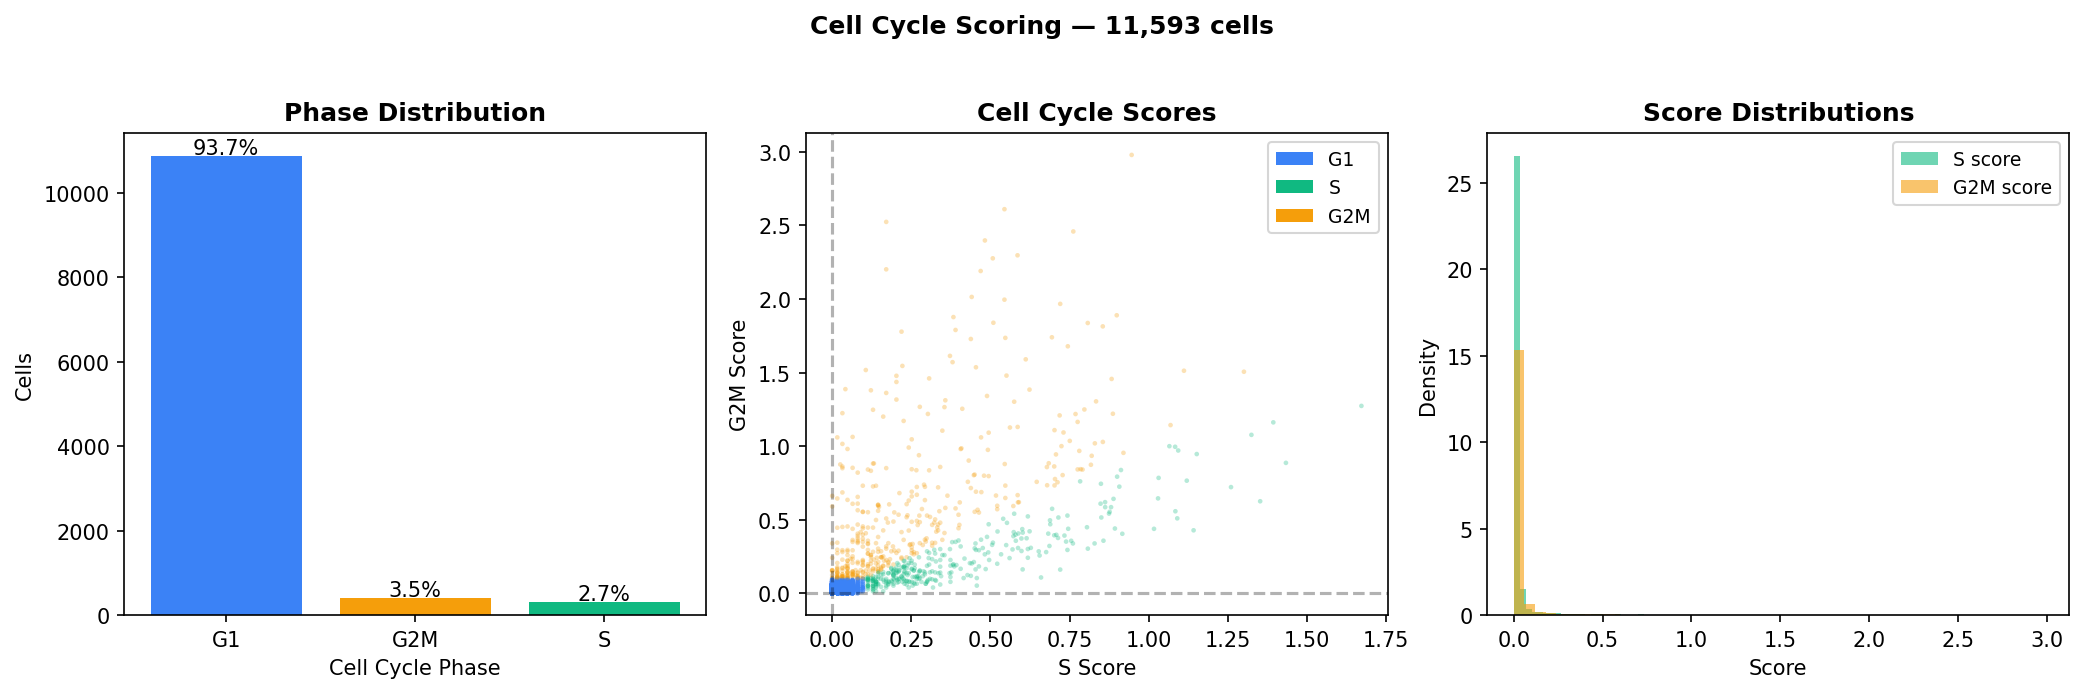

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
colors = {'G1': '#3b82f6', 'S': '#10b981', 'G2M': '#f59e0b'}

# Phase bar chart
pc = adata.obs['phase'].value_counts()
axes[0].bar(pc.index, pc.values, color=[colors[p] for p in pc.index])
axes[0].set_title('Phase Distribution', fontweight='bold')

# S vs G2M scatter
c = [colors.get(p, '#999') for p in adata.obs['phase']]
axes[1].scatter(adata.obs['s_score'], adata.obs['g2m_score'], c=c, alpha=0.3, s=5)
axes[1].set_xlabel('S Score')
axes[1].set_ylabel('G2M Score')
axes[1].set_title('Cell Cycle Scores', fontweight='bold')
axes[1].legend(handles=[Patch(fc=v, label=k) for k, v in colors.items()])

# Score histograms
axes[2].hist(adata.obs['s_score'], bins=50, alpha=0.6, color='#10b981', label='S', density=True)
axes[2].hist(adata.obs['g2m_score'], bins=50, alpha=0.6, color='#f59e0b', label='G2M', density=True)
axes[2].set_title('Score Distributions', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

## Key Points

- **G1 dominates** — most cells are in quiescent/gap phase (typical for post-mortem tissue)
- S and G2M scores separate clearly in 2D space
- All scores pre-computed by singlify — available immediately in `adata.obs`
- Use for: batch effect correction, proliferation analysis, regressing out cell cycle effects